# ENEM 2023 — Análise Exploratória

**Objetivo:** Controlando pelo contexto socioeconômico do aluno, estimar a associação entre frequentar uma escola privada e P(nota_media ≥ 700).
**Variável-alvo:** `nota_media >= 700` (média das 5 áreas — patamar competitivo para universidades públicas).

**Seções:**
1. Carga e exploração inicial
2. Distribuição do target e `nota_media`
3. Viz 1 — Gradiente de renda × performance
4. Viz 2 — Tesoura educacional (escolaridade materna vs. paterna)
5. Viz 3 — Desempenho por UF
6. Viz 4 — Efeito condicional escola × quartil de renda

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from src.paths import MICRODADOS, FIGS_DIR

FIGS_DIR.mkdir(parents=True, exist_ok=True)

# --- Estilo global ---
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

AZUL = '#1a4e8c'
LARANJA = '#e87722'
THRESHOLD = 700

## 1. Carga e Exploração Inicial

Microdado consolidado ENEM 2023 (separador `;`, encoding `latin-1`):
- **MICRODADOS_ENEM_2023.csv** — arquivo único keyed por `NU_INSCRICAO`, contendo notas (`NU_NOTA_*`), presença (`TP_PRESENCA_*`), escola (`TP_DEPENDENCIA_ADM_ESC`) e questionário socioeconômico (`Q001–Q023`).

Carregamos apenas as colunas necessárias via `usecols` para minimizar uso de memória (~16 colunas de ~180+).

In [2]:
SCORE_COLS = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
PRESENCE_COLS = ['TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT']
SOCIO_COLS = ['Q001', 'Q002', 'Q005', 'Q006', 'Q022', 'Q023', 'Q024', 'Q025']

MICRO_COLS = set(
    ['NU_INSCRICAO', 'SG_UF_PROVA', 'TP_DEPENDENCIA_ADM_ESC', 'TP_ESCOLA', 'TP_ENSINO']
    + SCORE_COLS
    + PRESENCE_COLS
    + SOCIO_COLS
    + ['IN_TREINEIRO', 'TP_ST_CONCLUSAO', 'TP_COR_RACA', 'TP_FAIXA_ETARIA', 'TP_SEXO']
)

print(f"Carregando MICRODADOS_ENEM_2023 ({MICRODADOS.stat().st_size / 1e9:.1f} GB)...")
df = pd.read_csv(
    MICRODADOS,
    sep=';',
    encoding='latin-1',
    usecols=lambda c: c in MICRO_COLS,
    decimal=',',
    low_memory=False,
)
print(f"  Shape: {df.shape}")
print(f"  Colunas socioeconômicas presentes: {[c for c in SOCIO_COLS if c in df.columns]}")

miss = df[SCORE_COLS + SOCIO_COLS + ['SG_UF_PROVA']].isnull().mean().sort_values(ascending=False)
print("\nProporção de missings:")
print(miss.to_string())

Carregando MICRODADOS_ENEM_2023 (1.8 GB)...
  Shape: (3933955, 27)
  Colunas socioeconômicas presentes: ['Q001', 'Q002', 'Q005', 'Q006', 'Q022', 'Q023', 'Q024', 'Q025']

Proporção de missings:
NU_NOTA_CN         0.315593
NU_NOTA_MT         0.315593
NU_NOTA_CH         0.282492
NU_NOTA_LC         0.282492
NU_NOTA_REDACAO    0.282492
Q001               0.000000
Q002               0.000000
Q005               0.000000
Q006               0.000000
Q022               0.000000
Q023               0.000000
Q024               0.000000
Q025               0.000000
SG_UF_PROVA        0.000000


In [3]:
# Garantir dtype numérico nas notas (caso decimal=',' não resolva em todas as versões do pandas)
for col in SCORE_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

## 2. Construção da `nota_media` e Distribuição do Target

Filtramos apenas participantes que realizaram todas as 5 provas.

In [4]:
# Filtro de qualidade da base:
# 1. Treineiros excluídos (IN_TREINEIRO == 0) — motivação diferente, ruído no target
# 2. Apenas concluintes ou concluindo em 2023 (TP_ST_CONCLUSAO IN [1, 2])
# 3. Presença em todas as 4 provas objetivas
n_orig = len(df)

treineiro_filter = (df['IN_TREINEIRO'] == 0) if 'IN_TREINEIRO' in df.columns else pd.Series([True] * len(df), index=df.index)
conclusao_filter = df['TP_ST_CONCLUSAO'].isin([1, 2]) if 'TP_ST_CONCLUSAO' in df.columns else pd.Series([True] * len(df), index=df.index)

presence_filter = pd.Series([True] * len(df), index=df.index)
for col in PRESENCE_COLS:
    if col in df.columns:
        presence_filter &= (df[col] == 1)

df_present = df[treineiro_filter & conclusao_filter & presence_filter].copy()
print(f"Original:              {n_orig:>10,}")
print(f"Após filtro treineiro: {int(treineiro_filter.sum()):>10,}  ({treineiro_filter.mean():.1%})")
print(f"Após filtro conclusão: {int((treineiro_filter & conclusao_filter).sum()):>10,}")
print(f"Após filtro presença:  {len(df_present):>10,}  ({len(df_present)/n_orig:.1%} do original)")

Original:               3,933,955
Após filtro treineiro:  3,313,888  (84.2%)
Após filtro conclusão:  3,296,465
Após filtro presença:   2,156,844  (54.8% do original)


In [5]:
# Calcular nota_media e remover quem tem nota inválida em qualquer área
df_present['nota_media'] = df_present[SCORE_COLS].mean(axis=1)
df_present = df_present.dropna(subset=['nota_media'])

# Variável-alvo
df_present['alta_performance'] = (df_present['nota_media'] >= THRESHOLD).astype(int)

n_total = len(df_present)
n_alta = df_present['alta_performance'].sum()
print(f"Base analítica: {n_total:,} participantes")
print(f"Alta performance (≥{THRESHOLD}): {n_alta:,} ({n_alta/n_total:.1%})")

Base analítica: 2,156,844 participantes
Alta performance (≥700): 117,327 (5.4%)


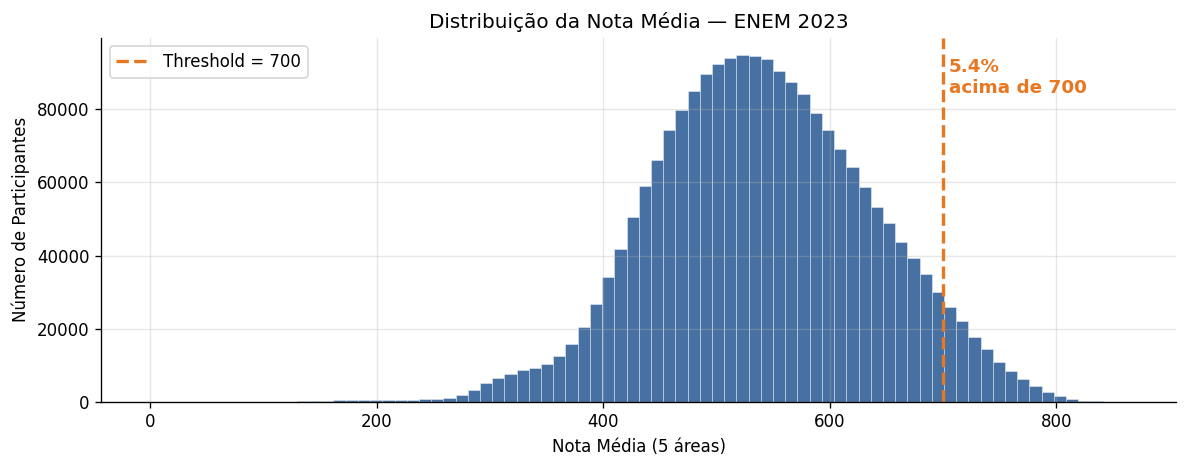

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_present['nota_media'], bins=80, color=AZUL, alpha=0.8, edgecolor='white', linewidth=0.3)
ax.axvline(THRESHOLD, color=LARANJA, linewidth=2, linestyle='--', label=f'Threshold = {THRESHOLD}')
ax.set_xlabel('Nota Média (5 áreas)')
ax.set_ylabel('Número de Participantes')
ax.set_title('Distribuição da Nota Média — ENEM 2023')
pct = n_alta / n_total
ax.text(THRESHOLD + 5, ax.get_ylim()[1] * 0.85,
        f'{pct:.1%}\nacima de {THRESHOLD}', color=LARANJA, fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / 'viz0_distribuicao_nota.png', dpi=150)
plt.show()

## 3. Visualização 1 — Gradiente de Renda × Performance

**Mensagem executiva:** A nota média cresce monotonicamente com a faixa de renda — o gap entre a menor e a maior faixa é o achado mais visceral da análise.

In [7]:
# Mapeamento Q006 → rótulo legível
# Q006 tem 17 faixas (A–Q). Agregamos em 9 bins para visualização limpa.
# Salário mínimo 2024 = R$1.320,00
RENDA_GROUP = {
    'A': 'Sem renda',
    'B': 'Até 1 SM',
    'C': '1–2 SM', 'D': '1–2 SM',
    'E': '2–3 SM', 'F': '2–3 SM',
    'G': '3–5 SM', 'H': '3–5 SM',
    'I': '5–7 SM', 'J': '5–7 SM',
    'K': '7–10 SM', 'L': '7–10 SM', 'M': '7–10 SM',
    'N': '10–15 SM', 'O': '10–15 SM',
    'P': '> 15 SM', 'Q': '> 15 SM',
}
RENDA_ORDER = ['Sem renda', 'Até 1 SM', '1–2 SM', '2–3 SM', '3–5 SM', '5–7 SM', '7–10 SM', '10–15 SM', '> 15 SM']

df_renda = df_present[df_present['Q006'].notna()].copy()
df_renda['renda_label'] = pd.Categorical(
    df_renda['Q006'].map(RENDA_GROUP),
    categories=RENDA_ORDER,
    ordered=True
)
df_renda = df_renda.dropna(subset=['renda_label'])
print(f"Registros com renda informada: {len(df_renda):,}")
df_renda['renda_label'].value_counts().sort_index()

Registros com renda informada: 2,156,844


renda_label
Sem renda    131232
Até 1 SM     663893
1–2 SM       605381
2–3 SM       269016
3–5 SM       232401
5–7 SM        92584
7–10 SM       73856
10–15 SM      44165
> 15 SM       44316
Name: count, dtype: int64

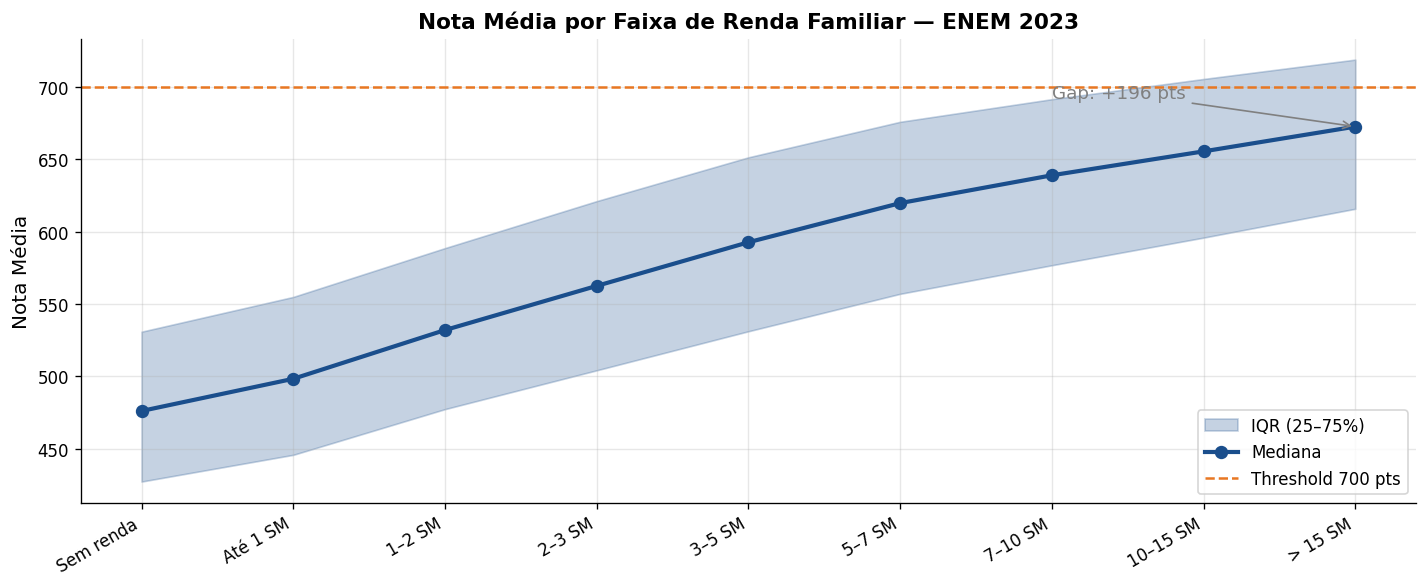

Gap de mediana (sem renda → > 15 SM): 196.4 pontos


In [8]:
renda_stats = (
    df_renda.groupby('renda_label', observed=True)['nota_media']
    .agg(['median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), 'count'])
    .reset_index()
)
renda_stats.columns = ['renda_label', 'mediana', 'q25', 'q75', 'n']

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(
    range(len(renda_stats)),
    renda_stats['q25'], renda_stats['q75'],
    alpha=0.25, color=AZUL, label='IQR (25–75%)'
)
ax.plot(range(len(renda_stats)), renda_stats['mediana'],
        color=AZUL, linewidth=2.5, marker='o', markersize=7, label='Mediana')
ax.axhline(THRESHOLD, color=LARANJA, linestyle='--', linewidth=1.5, label=f'Threshold {THRESHOLD} pts')

ax.set_xticks(range(len(renda_stats)))
ax.set_xticklabels(renda_stats['renda_label'], rotation=30, ha='right')
ax.set_ylabel('Nota Média', fontsize=12)
ax.set_title('Nota Média por Faixa de Renda Familiar — ENEM 2023', fontsize=13, fontweight='bold')
ax.legend(framealpha=0.8)

gap = renda_stats['mediana'].iloc[-1] - renda_stats['mediana'].iloc[0]
ax.annotate(
    f'Gap: +{gap:.0f} pts',
    xy=(len(renda_stats) - 1, renda_stats['mediana'].iloc[-1]),
    xytext=(len(renda_stats) - 3, renda_stats['mediana'].iloc[-1] + 20),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=11, color='gray'
)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'viz1_renda_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Gap de mediana (sem renda → > 15 SM): {gap:.1f} pontos")

## 4. Visualização 2 — Tesoura Educacional

**Mensagem executiva:** A escolaridade da mãe tem efeito mais pronunciado que a do pai — candidato com mãe pós-graduada tem nota sistematicamente superior. Isso orienta programas de suporte familiar.

In [9]:
# Mapeamento Q001/Q002 → escolaridade
ESCOL_MAP = {
    'A': 'Nunca estudou',
    'B': 'Fund. incompleto',
    'C': 'Fund. completo',
    'D': 'Médio incompleto',
    'E': 'Médio completo',
    'F': 'Superior completo',
    'G': 'Pós-graduação',
    'H': 'Não sei',
}
# 'H' excluído do eixo ordinal: "Não sei" não é um nível de escolaridade
ESCOL_ORDER = [k for k in ESCOL_MAP if k != 'H']

def compute_escol_stats(df, col, label):
    d = df[df[col].notna()].copy()
    d['escol_label'] = pd.Categorical(
        d[col].map(ESCOL_MAP),
        categories=[ESCOL_MAP[k] for k in ESCOL_ORDER],
        ordered=True
    )
    d = d.dropna(subset=['escol_label'])
    stats_df = (
        d.groupby('escol_label', observed=True)['nota_media']
        .agg(['mean', 'sem', 'count'])
        .reset_index()
    )
    stats_df.columns = ['escol_label', 'mean', 'sem', 'n']
    stats_df['ci95'] = 1.96 * stats_df['sem']
    stats_df['source'] = label
    return stats_df

mae_stats = compute_escol_stats(df_present, 'Q002', 'Mãe')
pai_stats = compute_escol_stats(df_present, 'Q001', 'Pai')

mae_stats.head(3)

,escol_label,mean,sem,n,ci95,source
0,Nunca estudou,470.600796,0.348931,53800,0.683904,Mãe
1,Fund. incompleto,495.908160,0.162652,255752,0.318798,Mãe
2,Fund. completo,510.754468,0.177584,231612,0.348065,Mãe


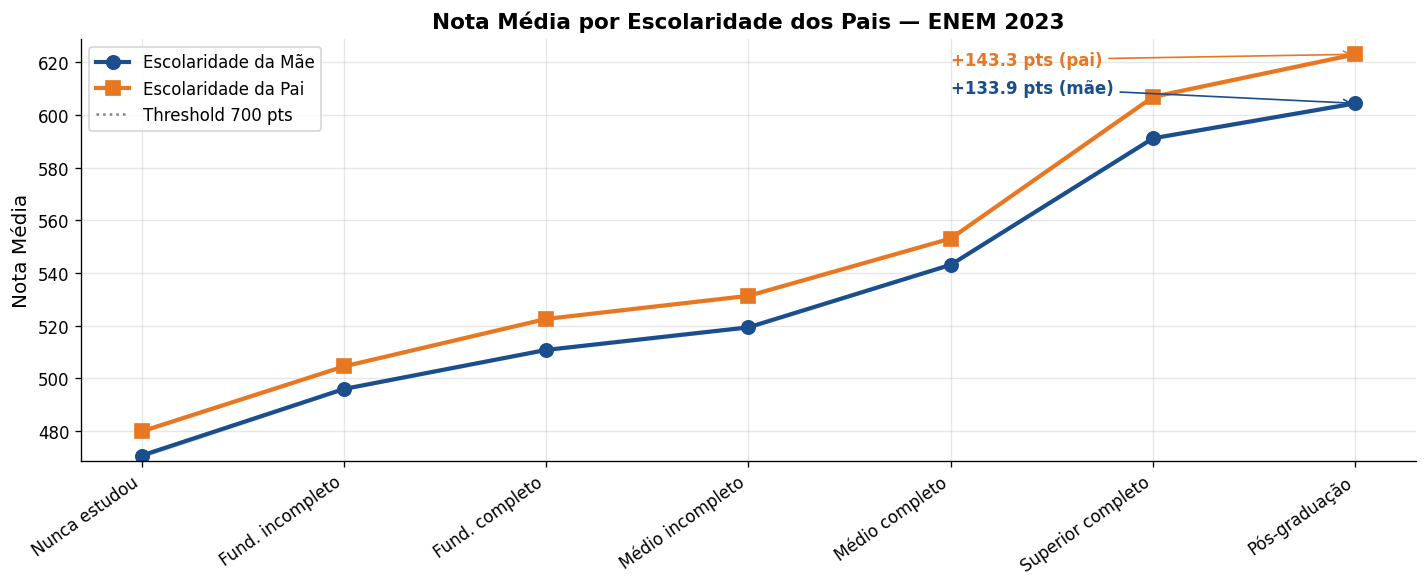

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

for stats_df, color, label, marker in [
    (mae_stats, AZUL, 'Escolaridade da Mãe', 'o'),
    (pai_stats, LARANJA, 'Escolaridade do Pai', 's'),
]:
    x = range(len(stats_df))
    ax.fill_between(
        x,
        stats_df['mean'] - stats_df['ci95'],
        stats_df['mean'] + stats_df['ci95'],
        alpha=0.15, color=color
    )
    ax.plot(x, stats_df['mean'], color=color, linewidth=2.5,
            marker=marker, markersize=8, label=label)

ax.axhline(THRESHOLD, color='gray', linestyle=':', linewidth=1.5, label=f'Threshold {THRESHOLD} pts')

ymin = min(mae_stats['mean'].min(), pai_stats['mean'].min()) - 2
ymax = max(mae_stats['mean'].max(), pai_stats['mean'].max()) + 6
ax.set_ylim([ymin, ymax])

ax.set_xticks(range(len(mae_stats)))
ax.set_xticklabels(mae_stats['escol_label'], rotation=35, ha='right')
ax.set_ylabel('Nota Média', fontsize=12)
ax.set_title('Nota Média por Escolaridade dos Pais — ENEM 2023', fontsize=13, fontweight='bold')
ax.legend(framealpha=0.8)

gap_mae = mae_stats['mean'].iloc[-1] - mae_stats['mean'].iloc[0]
gap_pai = pai_stats['mean'].iloc[-1] - pai_stats['mean'].iloc[0]
ax.annotate(
    f'+{gap_mae:.1f} pts (mãe)',
    xy=(len(mae_stats) - 1, mae_stats['mean'].iloc[-1]),
    xytext=(len(mae_stats) - 3, mae_stats['mean'].iloc[-1] + 4),
    arrowprops=dict(arrowstyle='->', color=AZUL),
    fontsize=10, color=AZUL, fontweight='bold'
)
ax.annotate(
    f'+{gap_pai:.1f} pts (pai)',
    xy=(len(pai_stats) - 1, pai_stats['mean'].iloc[-1]),
    xytext=(len(pai_stats) - 3, pai_stats['mean'].iloc[-1] - 4),
    arrowprops=dict(arrowstyle='->', color=LARANJA),
    fontsize=10, color=LARANJA, fontweight='bold'
)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'viz2_escolaridade_parental.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Visualização 3 — Desempenho por UF

**Mensagem executiva:** Há forte heterogeneidade regional — estados do Sul/Sudeste tendem a concentrar maior desempenho, enquanto Norte e Nordeste ficam abaixo da média nacional.

In [11]:
uf_stats = (
    df_present[df_present['SG_UF_PROVA'].notna()]
    .groupby('SG_UF_PROVA')
    .agg(
        nota_media_media=('nota_media', 'median'),
        pct_alta=('alta_performance', 'mean'),
        n=('nota_media', 'count')
    )
    .reset_index()
    .sort_values('nota_media_media', ascending=True)
)

media_nacional = df_present['nota_media'].median()
print(f"Mediana nacional: {media_nacional:.1f}")
uf_stats.tail(5)

Mediana nacional: 537.8


,SG_UF_PROVA,nota_media_media,pct_alta,n
18,RJ,553.34,0.065075,154483
22,RS,555.36,0.061220,91996
23,SC,559.48,0.061954,48084
25,SP,561.82,0.070634,327051
10,MG,565.64,0.085971,194984


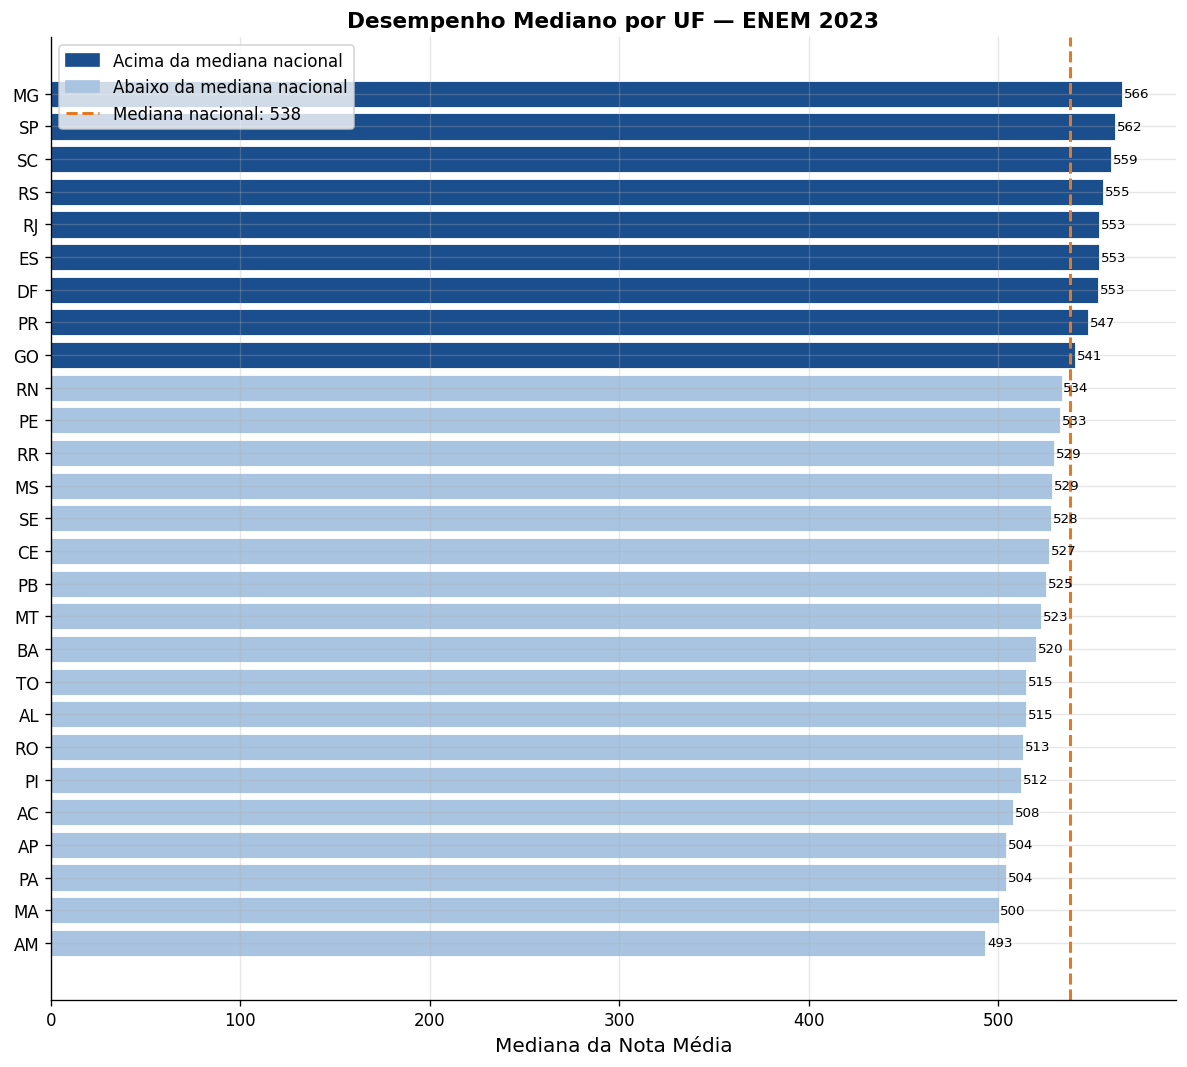

In [12]:
fig, ax = plt.subplots(figsize=(10, 9))

cores = [AZUL if v >= media_nacional else '#a8c4e0' for v in uf_stats['nota_media_media']]

bars = ax.barh(uf_stats['SG_UF_PROVA'], uf_stats['nota_media_media'],
               color=cores, edgecolor='white', linewidth=0.5)

ax.axvline(media_nacional, color=LARANJA, linestyle='--', linewidth=1.8)

for bar, val in zip(bars, uf_stats['nota_media_media']):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', ha='left', fontsize=8)

ax.set_xlabel('Mediana da Nota Média', fontsize=12)
ax.set_title('Desempenho Mediano por UF — ENEM 2023', fontsize=13, fontweight='bold')

patch_acima = mpatches.Patch(color=AZUL, label='Acima da mediana nacional')
patch_abaixo = mpatches.Patch(color='#a8c4e0', label='Abaixo da mediana nacional')
ax.legend(handles=[patch_acima, patch_abaixo,
                   plt.Line2D([0], [0], color=LARANJA, linestyle='--', linewidth=1.8,
                              label=f'Mediana nacional: {media_nacional:.0f}')],
          loc='upper left')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'viz3_mapa_uf.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Visualização 4 — Efeito Condicional Escola × Quartil de Renda

**Mensagem executiva:** Controlando pela renda do aluno, a escola privada eleva a probabilidade de atingir 700 em todos os quartis. A separação entre as duas curvas é o efeito incremental bruto que a rede pode reivindicar — o efeito *parcial* (controlando por todos os SES) será estimado no modelo (train.py).

In [13]:
# Efeito condicional: escola × quartil de renda
# Classificar tipo de escola: Federal (1), Pública estadual/municipal (2/3) → "Pública", Privada (4)
ESCOLA_MAP = {1: 'Federal', 2: 'Pública', 3: 'Pública', 4: 'Privada'}
df_cond = df_present.copy()
df_cond['tipo_escola'] = df_cond['TP_DEPENDENCIA_ADM_ESC'].map(ESCOLA_MAP)

# Criar quartil de renda a partir do ordinal de Q006
RENDA_ORDINAL = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5,
                 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11,
                 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16}
df_cond['renda_num'] = df_cond['Q006'].map(RENDA_ORDINAL)

# Manter apenas Pública vs. Privada (Federal é excepcional e tem baixa contagem)
df_cond_valid = df_cond.dropna(subset=['renda_num', 'tipo_escola'])
df_cond_valid = df_cond_valid[df_cond_valid['tipo_escola'].isin(['Pública', 'Privada'])].copy()

df_cond_valid['quartil_renda'] = pd.qcut(
    df_cond_valid['renda_num'],
    q=4,
    labels=['Q1\n(mais baixa)', 'Q2', 'Q3', 'Q4\n(mais alta)']
)

# P(≥700) por escola × quartil de renda
cond_stats = (
    df_cond_valid.groupby(['quartil_renda', 'tipo_escola'], observed=True)['alta_performance']
    .agg(['mean', 'count'])
    .reset_index()
)
cond_stats.columns = ['quartil_renda', 'tipo_escola', 'prob_alta', 'n']

print("P(≥700) por escola e quartil de renda:")
print(cond_stats.to_string())
efeito_bruto = (cond_stats[cond_stats['tipo_escola'] == 'Privada']['prob_alta'].mean() -
                cond_stats[cond_stats['tipo_escola'] == 'Pública']['prob_alta'].mean()) * 100
print(f"\nEfeito médio bruto (privada − pública, sem controle total): +{efeito_bruto:.1f} pp")

P(≥700) por escola e quartil de renda:
      quartil_renda tipo_escola  prob_alta       n
0  Q1\n(mais baixa)     Privada   0.041603   10432
1  Q1\n(mais baixa)     Pública   0.002910  194160
2                Q2     Privada   0.060005   27181
3                Q2     Pública   0.006207  139362
4                Q3     Privada   0.093864   57264
5                Q3     Pública   0.012936   92376
6   Q4\n(mais alta)     Privada   0.210323  119863
7   Q4\n(mais alta)     Pública   0.033220   36845

Efeito médio bruto (privada − pública, sem controle total): +8.8 pp


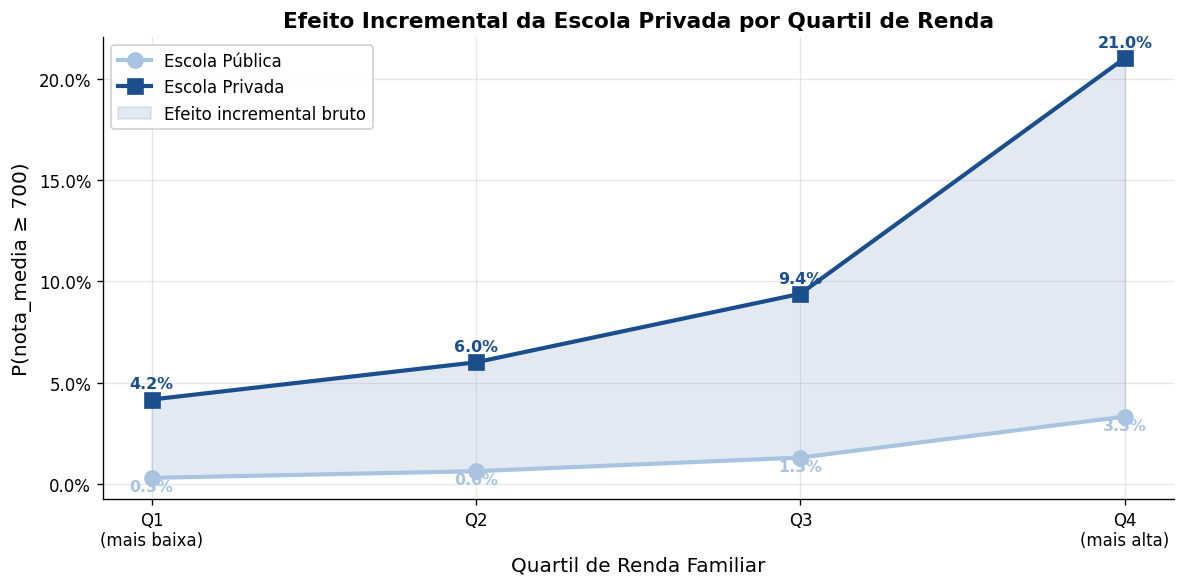

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

styles = [('Pública', '#a8c4e0', 'o'), ('Privada', AZUL, 's')]
for escola, color, marker in styles:
    dados = cond_stats[cond_stats['tipo_escola'] == escola].sort_values('quartil_renda')
    ax.plot(
        range(len(dados)),
        dados['prob_alta'] * 100,
        color=color, linewidth=2.5, marker=marker, markersize=9,
        label=f'Escola {escola}'
    )
    for i, row in enumerate(dados.itertuples()):
        offset = 0.4 if escola == 'Privada' else -0.8
        ax.text(i, row.prob_alta * 100 + offset, f'{row.prob_alta*100:.1f}%',
                ha='center', va='bottom', fontsize=9.5, color=color, fontweight='bold')

# Área de separação entre as curvas = efeito incremental bruto
pub = cond_stats[cond_stats['tipo_escola'] == 'Pública'].sort_values('quartil_renda')
priv = cond_stats[cond_stats['tipo_escola'] == 'Privada'].sort_values('quartil_renda')
ax.fill_between(
    range(len(pub)),
    pub['prob_alta'].values * 100,
    priv['prob_alta'].values * 100,
    alpha=0.12, color=AZUL, label='Efeito incremental bruto'
)

ax.set_xticks(range(4))
ax.set_xticklabels(['Q1\n(mais baixa)', 'Q2', 'Q3', 'Q4\n(mais alta)'])
ax.set_xlabel('Quartil de Renda Familiar', fontsize=12)
ax.set_ylabel('P(nota_media ≥ 700)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Efeito Incremental da Escola Privada por Quartil de Renda', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'viz4_efeito_condicional.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Síntese da EDA

**Três achados centrais para o deck:**

In [15]:
pct_alta = df_present['alta_performance'].mean()
gap_renda_num = renda_stats['mediana'].iloc[-1] - renda_stats['mediana'].iloc[0]
gap_mae_num = mae_stats['mean'].iloc[-1] - mae_stats['mean'].iloc[0]
internet_alta = (df_present.loc[df_present['alta_performance'] == 1, 'Q025'] == 'B').mean()
internet_mediano = (df_present.loc[df_present['alta_performance'] == 0, 'Q025'] == 'B').mean()
efeito_bruto_escola = (cond_stats[cond_stats['tipo_escola'] == 'Privada']['prob_alta'].mean() -
                       cond_stats[cond_stats['tipo_escola'] == 'Pública']['prob_alta'].mean()) * 100

print("=" * 60)
print("SÍNTESE PARA O DECK")
print("=" * 60)
print(f"1. {pct_alta:.1%} dos participantes (filtrados) atingiram média ≥ 700.")
print(f"2. Gap de renda: +{gap_renda_num:.0f} pts (sem renda → > 15 SM).")
print(f"3. Gap de escolaridade materna: +{gap_mae_num:.0f} pts (sem escola → pós-graduação).")
print(f"4. Acesso à internet: {internet_alta:.0%} dos alunos de alta perf. vs. {internet_mediano:.0%} dos demais.")
print(f"5. Efeito bruto escola (privada − pública): +{efeito_bruto_escola:.1f} pp em P(≥700).")
print("   → Efeito PARCIAL (controlando por todos os SES) será estimado em src/train.py")

SÍNTESE PARA O DECK
1. 5.4% dos participantes (filtrados) atingiram média ≥ 700.
2. Gap de renda: +196 pts (sem renda → > 15 SM).
3. Gap de escolaridade materna: +134 pts (sem escola → pós-graduação).
4. Acesso à internet: 99% dos alunos de alta perf. vs. 91% dos demais.
5. Efeito bruto escola (privada − pública): +8.8 pp em P(≥700).
   → Efeito PARCIAL (controlando por todos os SES) será estimado em src/train.py


In [16]:
# Salvar base analítica para uso no script de modelagem (src/train.py)
COLS_MODEL = [
    'nota_media', 'alta_performance', 'SG_UF_PROVA', 'TP_DEPENDENCIA_ADM_ESC',
    'TP_ESCOLA',
    'Q001', 'Q002', 'Q006',
    'Q022', 'Q024', 'Q025',
    'Q023',
    'TP_COR_RACA', 'TP_SEXO',
    'IN_TREINEIRO', 'TP_ST_CONCLUSAO', 'TP_ENSINO',
]
df_model = df_present[[c for c in COLS_MODEL if c in df_present.columns]].copy()

from src.paths import REPORTS_DIR
output_path = REPORTS_DIR / 'base_analitica.parquet'
df_model.to_parquet(output_path, index=False)
print(f"Base analítica salva: {output_path}")
print(f"Shape: {df_model.shape}")
print(f"Colunas: {list(df_model.columns)}")

Base analítica salva: /Users/rodrigolopesf/Documents/projetos-pessoais/technical_tests/case-inter-enem/reports/base_analitica.parquet
Shape: (2156844, 17)
Colunas: ['nota_media', 'alta_performance', 'SG_UF_PROVA', 'TP_DEPENDENCIA_ADM_ESC', 'TP_ESCOLA', 'Q001', 'Q002', 'Q006', 'Q022', 'Q024', 'Q025', 'Q023', 'TP_COR_RACA', 'TP_SEXO', 'IN_TREINEIRO', 'TP_ST_CONCLUSAO', 'TP_ENSINO']
